In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd


maternal_health = fetch_ucirepo(id=863)

x = maternal_health.data.features
y = maternal_health.data.targets

df = pd.concat([x, y], axis=1)
df.head()



,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [2]:
df.to_csv('../data/raw/maternal_health_risk.csv')

In [3]:
import sys
sys.path.append('..')
from src.eda import resumen_dimensiones

In [4]:
resumen_dimensiones(df)


El numero de filas es: 1014
El numero de columnas es: 7

Tipos de datos por columna: 
Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel          str
dtype: object


In [5]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [6]:
from src.preprocessing import convertir_farenheit_a_celsius

df = convertir_farenheit_a_celsius(df)
df['BodyTemp'].describe()

count    1014.000000
mean       37.036160
std         0.761880
min        36.666667
25%        36.666667
50%        36.666667
75%        36.666667
max        39.444444
Name: BodyTemp, dtype: float64

In [7]:
df.to_csv('../data/processed/maternal_health_risk_clean.csv', index = False)

In [8]:
df[df['HeartRate'] <30]

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
499,16,120,75,7.9,36.666667,7,low risk
908,16,120,75,7.9,36.666667,7,low risk


In [9]:
df.duplicated().sum()

np.int64(562)

In [10]:
df['RiskLevel'].value_counts(normalize=True)

RiskLevel
low risk     0.400394
mid risk     0.331361
high risk    0.268245
Name: proportion, dtype: float64

In [11]:
df[df.duplicated(keep=False)]['RiskLevel'].value_counts(normalize=True)

RiskLevel
mid risk     0.387991
low risk     0.337182
high risk    0.274827
Name: proportion, dtype: float64

## Nota sobre duplicados

Se detectaron 562 filas duplicadas (de 1014, ~55%). Dado que las variables predictoras 
son de naturaleza discreta (edad en años enteros, presión en incrementos de 5-10 mmHg, etc.), 
coincidencias exactas entre pacientes distintas son estadísticamente esperables, no 
necesariamente errores de captura.

La distribución de `RiskLevel` entre filas duplicadas (mid risk 38.8%, low risk 33.7%, 
high risk 27.5%) es similar a la del dataset completo (low risk 40.0%, mid risk 33.1%, 
high risk 26.8%), sin un desbalance extremo.

**Decisión:** se conservan los duplicados. Eliminarlos supondría perder ~55% del dataset 
(ya de por sí pequeño, 1014 filas) sin evidencia sólida de que se trate de errores, y 
alteraría ligeramente el balance de clases.


In [12]:
from src.preprocessing import excluir_valores_invalidos
df, filas_excluidas_hr = excluir_valores_invalidos(df, 'HeartRate', umbral_min = 30)
filas_excluidas_hr

Se excluyeron 2 filas por valores fisiologicamente imposibles en 'HeartRate' (< 30).


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
499,16,120,75,7.9,36.666667,7,low risk
908,16,120,75,7.9,36.666667,7,low risk


In [13]:
filas_excluidas_hr.to_csv('../data/processed/excluded_heartrate_outliers.csv', index=False)

## Nota sobre valores inválidos en HeartRate

Se excluyeron 2 filas con `HeartRate` = 7 bpm, un valor fisiológicamente incompatible con 
la vida (rango normal en reposo: 60-100 bpm). Ambas filas comparten valores idénticos en 
el resto de variables, sugiriendo un único error de captura del sistema IoT registrado 
dos veces. Las filas excluidas se conservan en 
`data/processed/excluded_heartrate_outliers.csv` para trazabilidad.


In [14]:
df.to_csv('../data/processed/maternal_health_risk_clean.csv', index=False)

In [15]:
resumen_dimensiones(df)

El numero de filas es: 1012
El numero de columnas es: 7

Tipos de datos por columna: 
Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel          str
dtype: object


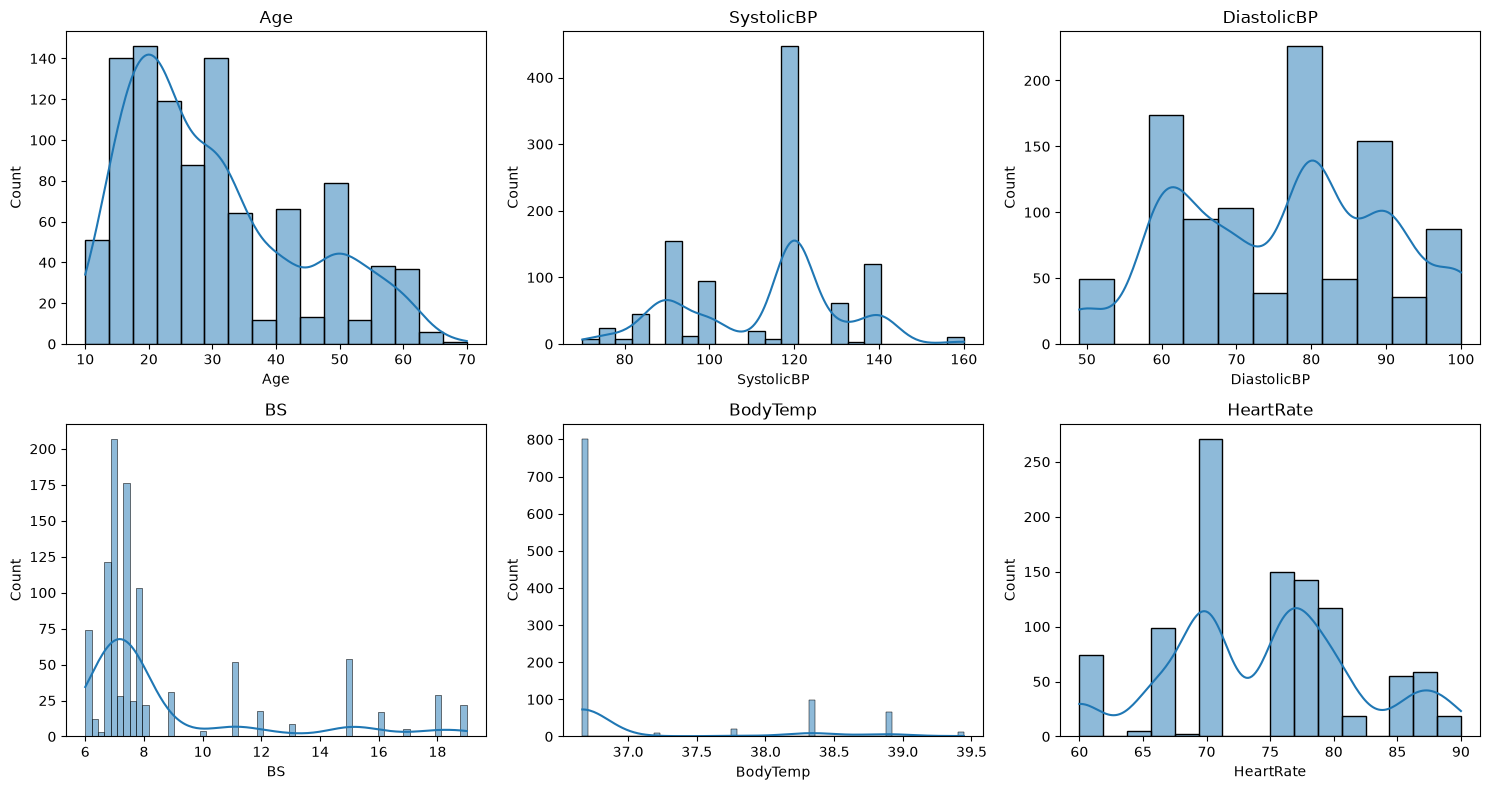

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

columnas_numericas = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']

fig, axes = plt.subplots(2,3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [17]:
df['BodyTemp'].value_counts()

BodyTemp
36.666667    802
38.333333     98
38.888889     66
37.777778     20
39.444444     13
37.222222     10
36.888889      2
37.000000      1
Name: count, dtype: int64

In [18]:
df.groupby('RiskLevel')['BodyTemp'].describe()

,count,mean,std,min,25%,50%,75%,max
RiskLevel,,,,,,,,
high risk,272.0,37.166258,0.865940,36.666667,36.666667,36.666667,37.777778,39.444444
low risk,404.0,36.872662,0.617436,36.666667,36.666667,36.666667,36.666667,39.444444
mid risk,336.0,37.129630,0.796544,36.666667,36.666667,36.666667,37.777778,39.444444


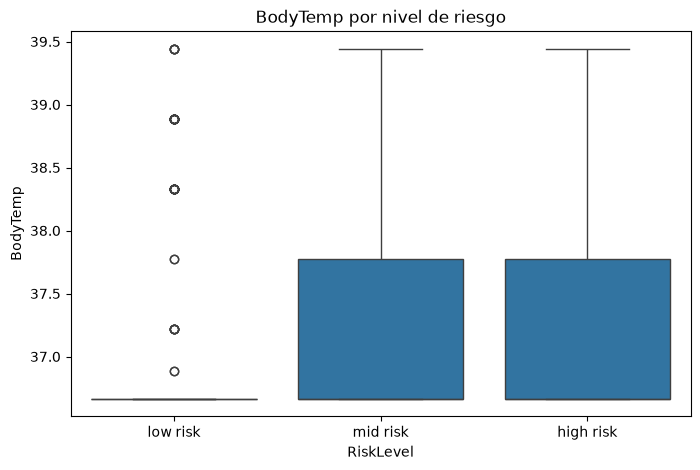

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='RiskLevel', y='BodyTemp', order = ['low risk', 'mid risk', 'high risk'])
plt.title('BodyTemp por nivel de riesgo')
plt.show()

In [20]:
umbral_fiebre = 37.2
df.groupby('RiskLevel')['BodyTemp'].apply(lambda x: (x > umbral_fiebre).mean())

RiskLevel
high risk    0.264706
low risk     0.111386
mid risk     0.267857
Name: BodyTemp, dtype: float64

## Hallazgo: BodyTemp — baja variabilidad, pero señal útil como indicador binario

El histograma univariado mostró que `BodyTemp` está dominada por un único valor 
(36.67°C, ~79% de las pacientes), un patrón de **"digit preference"**: es habitual en 
la toma manual de signos vitales que el personal registre el valor "normal" de 
referencia en lugar de la medición exacta, especialmente con equipos de campo poco 
precisos (recordar que este dataset se recolectó vía IoT en clínicas rurales de 
Bangladesh). Otras variables del dataset (`SystolicBP`, `DiastolicBP`, `HeartRate`) 
muestran el mismo patrón en sus histogramas.

Comparando `BodyTemp` entre clases de `RiskLevel`, la mediana es idéntica en las tres 
(36.67°C), lo que en un primer vistazo sugiere que la variable aporta poca información 
para distinguir el riesgo. Sin embargo, al definir fiebre como `BodyTemp > 37.2°C`, la 
proporción de pacientes con fiebre es:

| RiskLevel | % con fiebre |
|---|---|
| low risk | 11.1% |
| mid risk | 26.8% |
| high risk | 26.5% |

La proporción de fiebre en "mid" y "high risk" es más del doble que en "low risk", lo 
que sí es clínicamente coherente (la fiebre puede indicar infección, un factor de 
riesgo real en el embarazo). Esto indica que **la variable cruda (continua) es débil, 
pero contiene señal útil si se transforma en un indicador binario de fiebre**. 

**Nota (feature engineering, pendiente para el notebook de modelado):** evaluar la 
creación de una variable derivada `tiene_fiebre = (BodyTemp > 37.2)` en lugar de usar 
`BodyTemp` cruda como predictor.


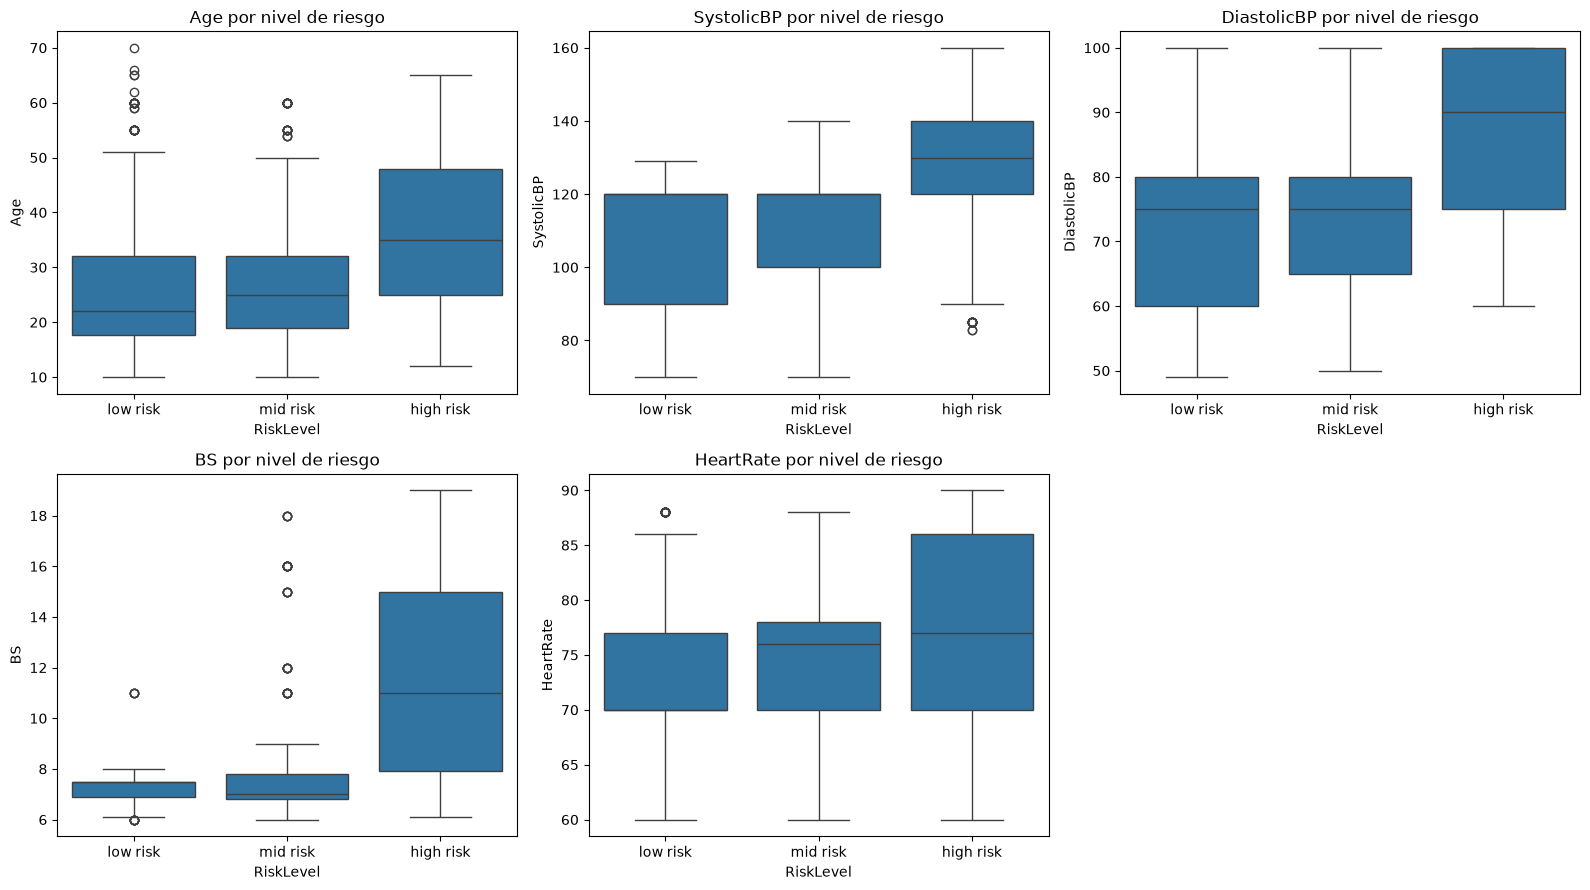

In [24]:
columnas_a_revisar = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'HeartRate']

fig, axes = plt.subplots(2,3, figsize=(16,9))
axes = axes.flatten()

for i, col in enumerate(columnas_a_revisar):
    sns.boxplot(data=df, x='RiskLevel', y=col, order = ['low risk', 'mid risk', 'high risk'], ax=axes[i])
    axes[i].set_title(f'{col} por nivel de riesgo')

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

In [22]:
print(df.shape)
print(df['RiskLevel'].unique())

(1012, 7)
<ArrowStringArray>
['high risk', 'low risk', 'mid risk']
Length: 3, dtype: str


In [23]:
df.dtypes

Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel          str
dtype: object

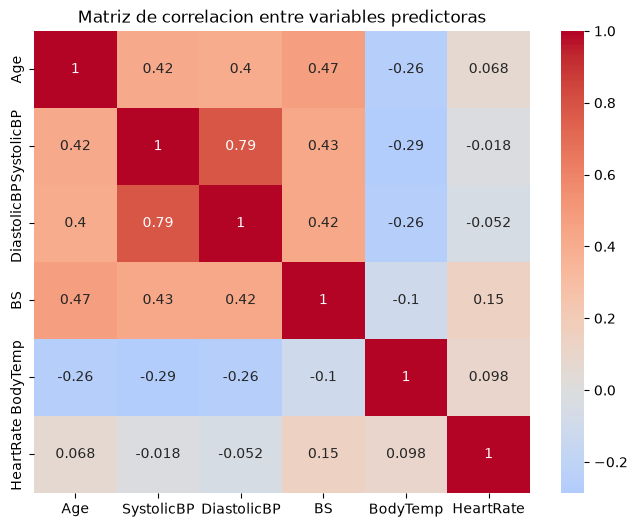

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(df[columnas_numericas].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de correlacion entre variables predictoras')
plt.show()

## Resumen de hallazgos del EDA

- **Limpieza de datos:** se corrigió la unidad de `BodyTemp` (Fahrenheit → Celsius); se 
  excluyeron 2 filas con `HeartRate` fisiológicamente inválido (7 bpm); se conservaron 
  562 duplicados tras confirmar que no distorsionan significativamente el balance de clases.
- **Calidad del dato:** varias variables (`SystolicBP`, `DiastolicBP`, `HeartRate`, 
  `BodyTemp`) muestran "digit preference" (redondeo a valores de referencia clínica), 
  típico de toma manual de signos vitales — una limitación real del dataset a tener en 
  cuenta al interpretar el modelo final.
- **BodyTemp:** poca variabilidad como variable continua, pero señal útil si se 
  transforma en indicador binario de fiebre (>37.2°C): 11.1% en low risk vs. ~26.5-26.8% 
  en mid/high risk.
- **Separación entre clases:** `SystolicBP`, `DiastolicBP` y `BS` muestran la mejor 
  separación visual entre niveles de riesgo. En casi todas las variables, "low risk" y 
  "mid risk" se solapan más entre sí que cualquiera de ellas con "high risk" — se espera 
  que el modelo tenga más dificultad distinguiendo esas dos clases entre sí.
- **Multicolinealidad:** `SystolicBP` y `DiastolicBP` correlacionan fuertemente (0.79), 
  algo clínicamente esperado. A considerar según el algoritmo elegido en el modelado.
